# Naive Bayes — Online Retail Dataset

This notebook applies the Gaussian Naive Bayes classifier to the Online Retail dataset. The aim is to classify customers as high-value or low-value based on their purchasing behaviour.

The model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrix analysis.

In [1]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# =====================================================
# 2. LOAD ONLINE RETAIL DATASET
# =====================================================

retail_2009 = pd.read_excel(
    "../dataset/online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

retail_2010 = pd.read_excel(
    "../dataset/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

retail = pd.concat(
    [retail_2009, retail_2010],
    ignore_index=True
)

print("Combined Retail Dataset Shape:", retail.shape)

display(retail.head())

Combined Retail Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# =====================================================
# 3. RETAIL DATA CLEANING
# =====================================================

retail_clean = retail.copy()

original_shape = retail_clean.shape

# Remove missing Customer IDs
retail_clean = retail_clean.dropna(subset=["Customer ID"])

# Remove cancelled invoices
retail_clean = retail_clean[
    ~retail_clean["Invoice"].astype(str).str.startswith("C")
]

# Remove invalid Quantity and Price values
retail_clean = retail_clean[retail_clean["Quantity"] > 0]
retail_clean = retail_clean[retail_clean["Price"] > 0]

# Convert InvoiceDate to datetime
retail_clean["InvoiceDate"] = pd.to_datetime(
    retail_clean["InvoiceDate"],
    errors="coerce"
)

# Remove invalid dates
retail_clean = retail_clean.dropna(subset=["InvoiceDate"])

# Create TotalPrice
retail_clean["TotalPrice"] = (
    retail_clean["Quantity"] * retail_clean["Price"]
)

# Remove duplicate rows
retail_clean = retail_clean.drop_duplicates()

# Reset index
retail_clean = retail_clean.reset_index(drop=True)

print("Original Shape:", original_shape)
print("Cleaned Shape:", retail_clean.shape)

display(retail_clean.head())

Original Shape: (1067371, 8)
Cleaned Shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
# =====================================================
# 4. RFM FEATURE ENGINEERING
# =====================================================

snapshot_date = retail_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AverageBasketValue=("TotalPrice", "mean"),
    TotalQuantity=("Quantity", "sum")
).reset_index()

rfm = rfm.rename(columns={"Customer ID": "CustomerID"})

# Log transformations to reduce skewness
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Recency_log"] = np.log1p(rfm["Recency"])

# Create target variable — top 25% by Monetary value = high-value
threshold = rfm["Monetary"].quantile(0.75)

rfm["HighValueCustomer"] = (
    rfm["Monetary"] >= threshold
).astype(int)

print("RFM Shape:", rfm.shape)

print("\nHigh Value Customer Distribution:")
display(rfm["HighValueCustomer"].value_counts().to_frame("Count"))

display(rfm.head())

RFM Shape: (5878, 10)

High Value Customer Distribution:


,Count
HighValueCustomer,
0,4408
1,1470


,CustomerID,Recency,Frequency,Monetary,AverageBasketValue,TotalQuantity,Monetary_log,Frequency_log,Recency_log,HighValueCustomer
0,12346.0,326,12,77556.46,2281.072353,74285,11.258774,2.564949,5.789960,1
1,12347.0,2,8,4921.53,22.169054,2967,8.501578,2.197225,1.098612,1
2,12348.0,75,5,2019.40,39.596078,2714,7.611051,1.791759,4.330733,0
3,12349.0,19,4,4428.69,25.306800,1624,8.396085,1.609438,2.995732,1
4,12350.0,310,1,334.40,19.670588,197,5.815324,0.693147,5.739793,0


In [5]:
# =====================================================
# 5. TRAIN-TEST SPLIT AND FEATURE SCALING
# =====================================================

X_retail = rfm.drop(
    columns=["CustomerID", "HighValueCustomer"]
)

y_retail = rfm["HighValueCustomer"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_retail,
    y_retail,
    test_size=0.2,
    random_state=42,
    stratify=y_retail
)

scaler_retail = StandardScaler()

X_train_r_scaled = scaler_retail.fit_transform(X_train_r)
X_test_r_scaled = scaler_retail.transform(X_test_r)

X_train_r_scaled = pd.DataFrame(
    X_train_r_scaled,
    columns=X_train_r.columns
)

X_test_r_scaled = pd.DataFrame(
    X_test_r_scaled,
    columns=X_test_r.columns
)

print("Training Shape:", X_train_r_scaled.shape)
print("Testing Shape:", X_test_r_scaled.shape)

display(X_train_r_scaled.head())

Training Shape: (4702, 8)
Testing Shape: (1176, 8)


,Recency,Frequency,Monetary,AverageBasketValue,TotalQuantity,Monetary_log,Frequency_log,Recency_log
0,1.988585,-0.386783,-0.190614,-0.075552,-0.191838,-1.866344,-1.049029,1.260993
1,1.060042,0.971808,-0.000561,-0.083827,-0.099407,0.858437,1.832304,1.020414
2,0.002932,-0.243773,-0.169389,-0.113790,-0.167620,-0.605130,-0.199659,0.550405
3,1.245751,-0.315278,-0.068290,0.118477,-0.164553,0.548902,-0.552179,1.076330
4,2.488570,-0.386783,-0.184826,-0.104345,-0.188453,-1.268143,-1.049029,1.360711


In [6]:
# =====================================================
# 6. TRAIN GAUSSIAN NAIVE BAYES MODEL
# =====================================================

nb_model = GaussianNB()

nb_model.fit(
    X_train_r_scaled,
    y_train_r
)

nb_pred = nb_model.predict(X_test_r_scaled)

nb_prob = nb_model.predict_proba(X_test_r_scaled)[:, 1]

print("Gaussian Naive Bayes Retail Classification Report:")

print(
    classification_report(
        y_test_r,
        nb_pred,
        zero_division=0
    )
)

Gaussian Naive Bayes Retail Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       882
           1       0.93      0.93      0.93       294

    accuracy                           0.96      1176
   macro avg       0.95      0.95      0.95      1176
weighted avg       0.96      0.96      0.96      1176



In [7]:
# =====================================================
# 7. NAIVE BAYES PERFORMANCE METRICS
# =====================================================

nb_results = pd.DataFrame({
    "Dataset": ["Online Retail"],
    "Model": ["Gaussian Naive Bayes"],
    "Accuracy": [accuracy_score(y_test_r, nb_pred)],
    "Precision": [precision_score(y_test_r, nb_pred, zero_division=0)],
    "Recall": [recall_score(y_test_r, nb_pred, zero_division=0)],
    "F1 Score": [f1_score(y_test_r, nb_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_r, nb_prob)]
})

display(nb_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Gaussian Naive Bayes,0.964,0.932,0.925,0.928,0.992


In [8]:
# =====================================================
# 8. TRAIN VS TEST PERFORMANCE CHECK
# =====================================================

nb_train_pred = nb_model.predict(X_train_r_scaled)

train_test_comparison = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [
        accuracy_score(y_train_r, nb_train_pred),
        accuracy_score(y_test_r, nb_pred)
    ],
    "Precision": [
        precision_score(y_train_r, nb_train_pred, zero_division=0),
        precision_score(y_test_r, nb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_train_r, nb_train_pred, zero_division=0),
        recall_score(y_test_r, nb_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_train_r, nb_train_pred, zero_division=0),
        f1_score(y_test_r, nb_pred, zero_division=0)
    ]
})

display(train_test_comparison.round(3))

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Data,0.958,0.933,0.895,0.914
1,Testing Data,0.964,0.932,0.925,0.928


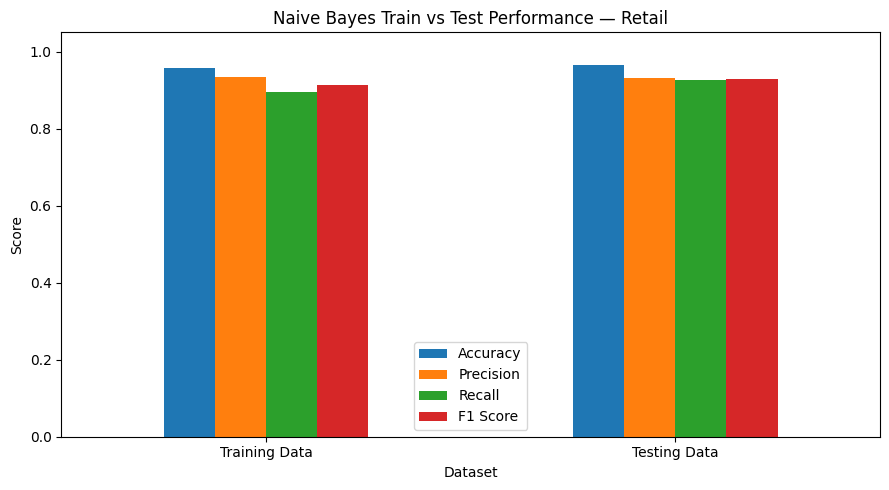

In [9]:
# =====================================================
# 9. TRAIN VS TEST PERFORMANCE VISUALISATION
# =====================================================

train_test_comparison.set_index("Dataset").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Naive Bayes Train vs Test Performance — Retail")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

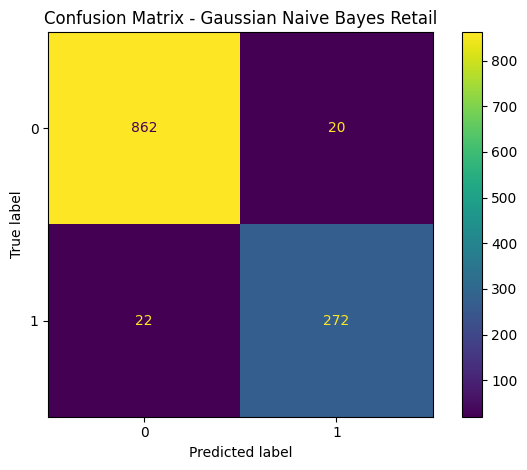

In [10]:
# =====================================================
# 10. CONFUSION MATRIX
# =====================================================

ConfusionMatrixDisplay.from_predictions(
    y_test_r,
    nb_pred
)

plt.title("Confusion Matrix - Gaussian Naive Bayes Retail")
plt.tight_layout()
plt.show()

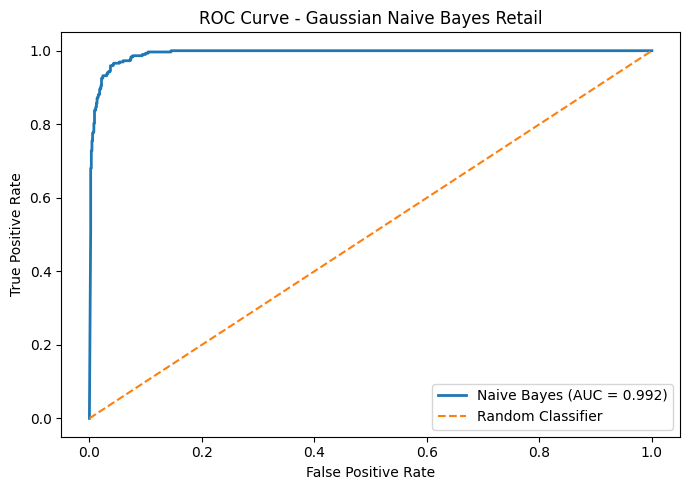

In [11]:
# =====================================================
# 11. ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(
    y_test_r,
    nb_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Naive Bayes (AUC = {roc_auc_score(y_test_r, nb_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Gaussian Naive Bayes Retail")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

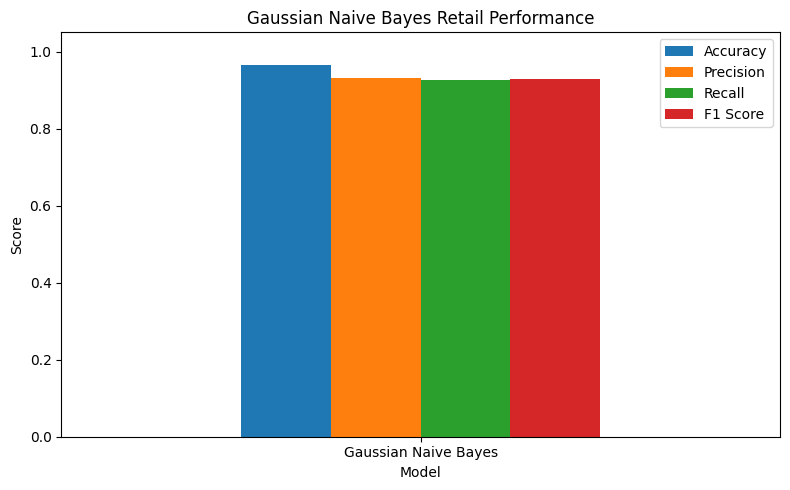

In [12]:
# =====================================================
# 12. PERFORMANCE METRICS VISUALISATION
# =====================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

nb_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Gaussian Naive Bayes Retail Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# 13. SAVE NAIVE BAYES RETAIL RESULTS
# =====================================================

nb_results.to_csv(
    "../results/Naive_Bayes_retail_results.csv",
    index=False
)

print("Naive Bayes retail results saved successfully.")

from google.colab import files
files.download("../results/Naive_Bayes_retail_results.csv")

Naive Bayes retail results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Naive Bayes Retail Summary

The Gaussian Naive Bayes model was applied to the Online Retail dataset to classify customers as high-value or low-value. RFM-based features — Recency, Frequency, Monetary value, Average Basket Value, and Total Quantity — were used as input features, with log transformations applied to reduce skewness.

The model achieved an Accuracy of 0.964, Precision of 0.932, Recall of 0.925, F1-score of 0.928, and ROC-AUC of 0.992. These results show that Gaussian Naive Bayes was able to distinguish high-value from low-value customers effectively.

The train vs test comparison showed that performance was consistent across both sets, indicating that the model generalised well and was not overfitting.

The ROC curve confirmed strong class separation with an AUC of 0.992. The confusion matrix showed that the model made very few misclassifications across both classes.

One limitation is that Naive Bayes assumes feature independence, which does not fully hold here since Frequency, Monetary value, and Total Quantity are correlated. Despite this, the model still performed well, making it a strong probabilistic baseline for comparison with other classification techniques.